In [30]:
from matplotlib.backends.backend_pdf import PdfPages
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [6]:
import zipfile

with zipfile.ZipFile("titanic.zip", "r") as zip_ref:
    zip_ref.extractall("titanic")

In [7]:
import os

print(os.listdir("titanic"))

['train.csv', 'test.csv', 'gender_submission.csv']


In [8]:
import pandas as pd

train = pd.read_csv("titanic/train.csv")
test = pd.read_csv("titanic/test.csv")
submission_gender = pd.read_csv("titanic/gender_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
print(train.shape)

(891, 12)


In [11]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [12]:
print(train.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [13]:
# Check missing values
print(train.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


<Axes: >

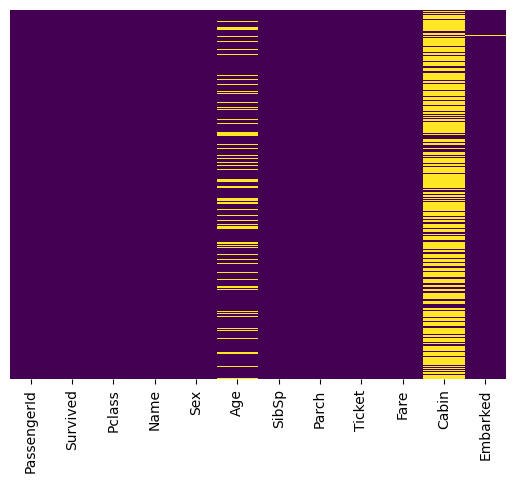

In [14]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

<Axes: xlabel='Survived', ylabel='count'>

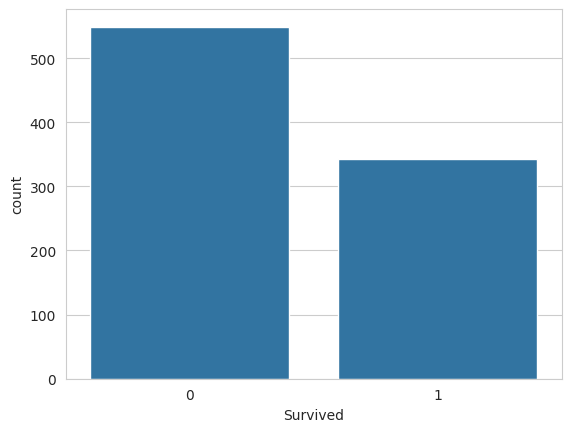

In [16]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',data=train)

<Axes: xlabel='Survived', ylabel='count'>

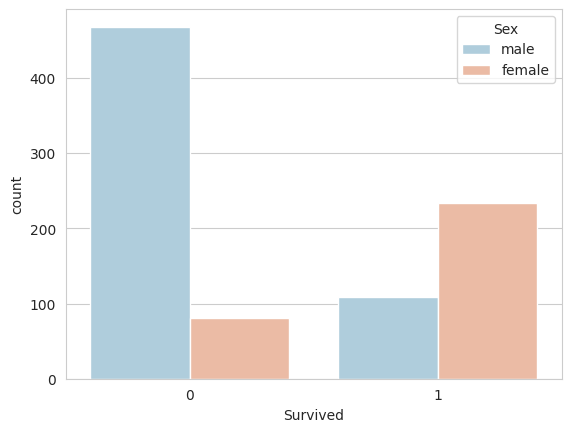

In [19]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Sex',data=train,palette='RdBu_r')

<Axes: xlabel='Survived', ylabel='count'>

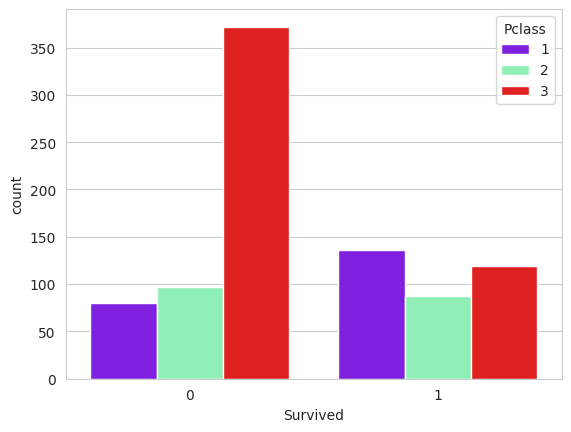

In [17]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Pclass',data=train,palette='rainbow')

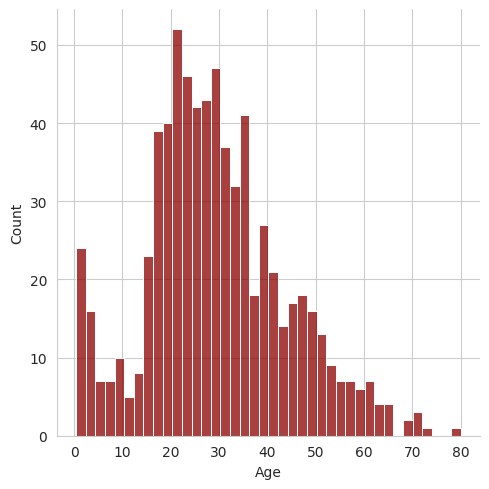

In [18]:
sns.displot(train['Age'].dropna(),kde=False,color='darkred',bins=40)

In [21]:
def get_lifecycle(age):
    if age < 13:
        return 'Child'
    elif age < 20:
        return 'Teenager'
    elif age < 60:
        return 'Adult'
    else:
        return 'Senior'

train['Lifecycle'] = train['Age'].apply(get_lifecycle)

In [22]:
lifecycle_mapping = {
    'Child': 1,
    'Teenager': 2,
    'Adult': 3,
    'Senior': 4
}

In [23]:
train['Lifecycle'] = train['Lifecycle'].map(lifecycle_mapping)

In [24]:
train[['Age', 'Lifecycle']].head(10)

,Age,Lifecycle
0,22.0,3
1,38.0,3
2,26.0,3
3,35.0,3
4,35.0,3
5,NaN,4
6,54.0,3
7,2.0,1
8,27.0,3
9,14.0,2


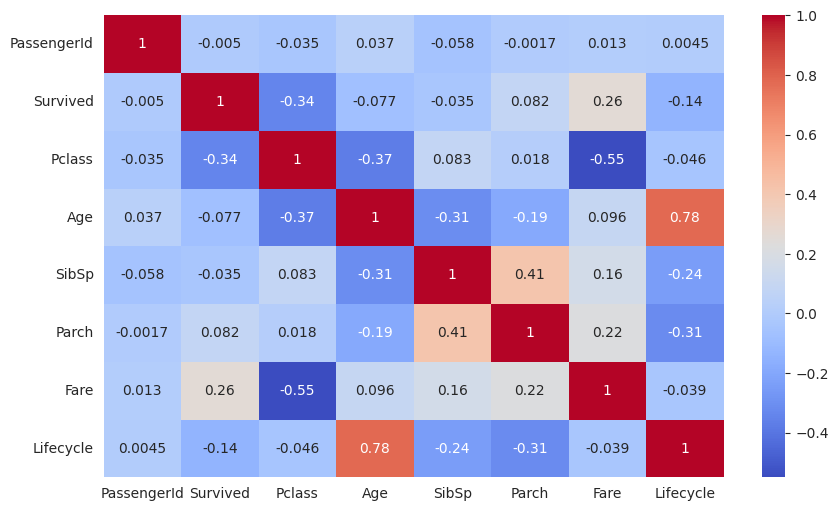

In [25]:
plt.figure(figsize=(10, 6))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [31]:
pdf = PdfPages('titanic_eda_report.pdf')

# Page 1: Missing Values Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
pdf.savefig()
plt.close()
# Page 2: Survival Analysis
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Sex', data=train, palette='RdBu_r')
plt.title('Survival Analysis by Sex')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.tight_layout()
pdf.savefig()
plt.close()
# Page 3: Age Distribution
plt.figure(figsize=(10, 6))
train['Age'].hist(bins=30, color='darkred', alpha=0.3)
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.tight_layout()
pdf.savefig()
plt.close()

# Page 4: Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
pdf.savefig()
plt.close()

pdf.close()

print("titanic_eda_report.pdf created successfully with 4 pages!")

files.download('titanic_eda_report.pdf')

titanic_eda_report.pdf created successfully with 4 pages!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
# Check duplicate rows
print("Duplicate rows:", train.duplicated().sum())

Duplicate rows: 0


In [33]:
# Remove duplicate rows
train = train.drop_duplicates()

print("Duplicate rows after cleaning:", train.duplicated().sum())

Duplicate rows after cleaning: 0


In [34]:
# Check incorrect values

# Check Age
if (train['Age'] < 0).any():
    print("Incorrect Age values found")
else:
    print("Age: No incorrect values")

# Check Fare
if (train['Fare'] < 0).any():
    print("Incorrect Fare values found")
else:
    print("Fare: No incorrect values")

# Check Pclass
if (~train['Pclass'].isin([1, 2, 3])).any():
    print("Incorrect Pclass values found")
else:
    print("Pclass: No incorrect values")

# Check Survived
if (~train['Survived'].isin([0, 1])).any():
    print("Incorrect Survived values found")
else:
    print("Survived: No incorrect values")

Age: No incorrect values
Fare: No incorrect values
Pclass: No incorrect values
Survived: No incorrect values


In [35]:
# Check unnecessary columns

unnecessary_columns = ['PassengerId', 'Name', 'Ticket', 'Cabin']

for column in unnecessary_columns:
    if column in train.columns:
        print(column, ": Unnecessary column found")
    else:
        print(column, ": Column not found")

PassengerId : Unnecessary column found
Name : Unnecessary column found
Ticket : Unnecessary column found
Cabin : Unnecessary column found
